### References

https://github.com/gabrielziegler3/xgboost-multiclass-multilabel/blob/master/xgboost-multiclass/multiclass-frog-classification.ipynb


In [1]:
import os

import mlflow
import mlflow.xgboost
import mlflow.sklearn

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from IPython.display import display
from sklearn.feature_selection import mutual_info_regression
import plotly

from sklearn.model_selection import train_test_split
from xgboost.sklearn import XGBClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import recall_score, f1_score, precision_score, precision_recall_fscore_support
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score, recall_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.datasets import make_classification

import matplotlib.pyplot as plt
from matplotlib import pyplot

In [2]:
not_use_cols = ['date']
#
pred_cols= [ 'f5s_average', 'f5s_10c_arrow', 'f5s_15c_arrow', 'f5s_20c_arrow',  'f5s_25c_arrow' ]
X_cols  = ['high', 'volume', 'average', 'barCount',
           'h1s_high',  'h1s_low', 	'h1s_barCount', 'h1s_volume', 'h1s_average',
           'h2s_high', 	'h2s_low', 	'h2s_barCount', 'h2s_volume', 'h2s_average',
           'h3s_high', 	'h3s_low', 	'h3s_barCount', 'h3s_volume', 'h3s_average',
           'h4s_high', 	'h4s_low', 	'h4s_barCount', 'h4s_volume', 'h4s_average',
           'bid_avg', 	'ask_max', 	'bid_min', 	'ask_avg',
           'h1s_ask_max', 	'h1s_bid_min', 	'h1s_bid_avg', 	'h1s_ask_avg', 	'h2s_ask_max', 	'h2s_bid_min', 	'h2s_bid_avg', 	'h2s_ask_avg', 	'h3s_ask_max', 	'h3s_bid_min', 	'h3s_bid_avg', 	'h3s_ask_avg', 	'h4s_ask_max', 	'h4s_bid_min', 	'h4s_bid_avg', 	'h4s_ask_avg',
           'vix'
           ]
y_cols = pred_cols
bin_counts = 3


## mlflow logging

### [reference page](https://learn.microsoft.com/en-us/azure/machine-learning/how-to-log-view-metrics?tabs=interactive)

In [3]:
mlflow.set_experiment("vol-xgboost")
mlflow.xgboost.autolog()

In [4]:
plt.style.use("seaborn-whitegrid")
plt.rc("figure", autolayout=True)
plt.rc(
    "axes",
    labelweight="bold",
    labelsize="large",
    titleweight="bold",
    titlesize=14,
    titlepad=10,
)

# Code

## load data / split data

In [6]:
%%time
def load_data():
    _data1 = pd.read_csv("./contract-TSLA/TSLA-BID_ASK.csv", low_memory=False)
    _data1.set_index('date')
    _data1 = _data1.sort_index()

    _data2 = pd.read_csv("./contract-TSLA/TSLA-TRADES.csv", low_memory=False)
    _data2.set_index('date')
    _data2 = _data2.sort_index()

    _data3 = pd.merge(left=_data2, right=_data1, how="outer", on="date", validate="one_to_one")
    print ("size", _data3.shape)
    mlflow.log_param("Size", _data3.shape)
    mlflow.log_param("X cols", X_cols)
    mlflow.log_param("y col",  y_cols[1:])
    _data4 = _data3.copy(deep=True)
    _data4 = _data4.head(1000000)

    return _data4

data = load_data()

size (3679206, 56)
CPU times: user 34.5 s, sys: 7.16 s, total: 41.6 s
Wall time: 41.7 s


In [7]:
data.columns

Index(['date', 'open', 'high', 'low', 'close', 'volume', 'average', 'barCount',
       'date2_str_x', 'h1s_high', 'h1s_low', 'h1s_barCount', 'h1s_volume',
       'h1s_average', 'h2s_high', 'h2s_low', 'h2s_barCount', 'h2s_volume',
       'h2s_average', 'h3s_high', 'h3s_low', 'h3s_barCount', 'h3s_volume',
       'h3s_average', 'h4s_high', 'h4s_low', 'h4s_barCount', 'h4s_volume',
       'h4s_average', 'f5s_average', 'f5s_10c_arrow', 'f5s_15c_arrow',
       'f5s_20c_arrow', 'f5s_25c_arrow', 'bid_avg', 'ask_max', 'bid_min',
       'ask_avg', 'date2_str_y', 'h1s_ask_max', 'h1s_bid_min', 'h1s_bid_avg',
       'h1s_ask_avg', 'h2s_ask_max', 'h2s_bid_min', 'h2s_bid_avg',
       'h2s_ask_avg', 'h3s_ask_max', 'h3s_bid_min', 'h3s_bid_avg',
       'h3s_ask_avg', 'h4s_ask_max', 'h4s_bid_min', 'h4s_bid_avg',
       'h4s_ask_avg', 'vix'],
      dtype='object')

In [8]:
data.shape

(1000000, 56)

In [9]:
def rebase(low,
           c1, c2, c3, c4, c5, c6, c7, c8, c9, c10,
           c11, c12, c13, c14, c15, c16, c17, c18, c19, c20,
           c21, c22, c23, c24, c25, c26, c27, c28, c29, c30,
           c31, c32, c33, c34, c35, c36, c37):
   return pd.Series([
       c1 - low, c2 - low, c3 - low, c4 - low, c5 - low,
       c6 - low, c7 - low, c8 - low, c9 - low, c10 - low,
       c11 - low, c12 - low, c13 - low, c14 - low, c15 - low,
       c16 - low, c17 - low, c18 - low, c19 - low, c20 - low,
       c21 - low, c22 - low, c23 - low, c24 - low, c25 - low,
       c26 - low, c27 - low, c28 - low, c29 - low, c30 - low,
       c31 - low, c32 - low, c33 - low, c34 - low, c35 - low,
       c36 - low, c37 - low ])

In [10]:
data.head(100)

,date,open,high,low,close,volume,average,barCount,date2_str_x,h1s_high,...,h2s_ask_avg,h3s_ask_max,h3s_bid_min,h3s_bid_avg,h3s_ask_avg,h4s_ask_max,h4s_bid_min,h4s_bid_avg,h4s_ask_avg,vix
0,2022-06-24 12:29:54,243.5433,243.5433,243.5433,243.5433,0.00,243.543,0.0,2022-06-24,NaN,...,243.5867,243.6000,243.5000,243.5003,243.5933,243.5967,243.4933,243.5130,243.5967,27.40
1,2022-06-24 12:29:55,243.5833,243.5833,243.5833,243.5833,3.27,243.583,1.0,2022-06-24,243.5433,...,243.5867,243.5933,243.5000,243.5000,243.5867,243.6000,243.5000,243.5003,243.5933,27.40
2,2022-06-24 12:29:56,243.5433,243.5433,243.5433,243.5433,15.00,243.543,1.0,2022-06-24,243.5833,...,243.5833,243.5867,243.5000,243.5000,243.5867,243.5933,243.5000,243.5000,243.5867,27.40
3,2022-06-24 12:29:57,243.5433,243.5433,243.5433,243.5433,3.00,243.543,1.0,2022-06-24,243.5433,...,243.5833,243.5867,243.5000,243.5000,243.5833,243.5867,243.5000,243.5000,243.5867,27.40
4,2022-06-24 12:29:58,243.5500,243.5500,243.5500,243.5500,6.00,243.550,1.0,2022-06-24,243.5433,...,243.5867,243.5833,243.5000,243.5033,243.5833,243.5867,243.5000,243.5000,243.5833,27.40
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,2022-06-24 12:31:29,243.4600,243.4633,243.4600,243.4600,3.00,243.461,1.0,2022-06-24,243.4200,...,243.4200,243.4200,243.3067,243.3433,243.4200,243.4200,243.3067,243.3070,243.3800,27.39
96,2022-06-24 12:31:30,243.4600,243.4633,243.4600,243.4600,0.00,243.460,0.0,2022-06-24,243.4633,...,243.4760,243.4200,243.3067,243.3067,243.4200,243.4200,243.3067,243.3433,243.4200,27.39
97,2022-06-24 12:31:31,243.4200,243.4233,243.4200,243.4200,10.50,243.420,1.0,2022-06-24,243.4633,...,243.4767,243.5033,243.3067,243.3857,243.4760,243.4200,243.3067,243.3067,243.4200,27.36
98,2022-06-24 12:31:32,243.4200,243.4233,243.4200,243.4200,0.00,243.420,0.0,2022-06-24,243.4233,...,243.4237,243.4833,243.3867,243.3867,243.4767,243.5033,243.3067,243.3857,243.4760,27.36


In [11]:
%%time
data[['open', 'high', 'close', 'average',
	'h1s_high', 'h1s_low', 'h1s_average',
	'h2s_high', 'h2s_low', 'h2s_average',
	'h3s_high', 'h3s_low', 'h3s_average',
	'h4s_high', 'h4s_low', 'h4s_average',
	'f5s_average',
	'bid_avg', 'ask_max', 'bid_min', 'ask_avg',
	'h1s_ask_max', 'h1s_bid_min', 'h1s_bid_avg', 'h1s_ask_avg',
	'h2s_ask_max', 'h2s_bid_min', 'h2s_bid_avg', 'h2s_ask_avg',
	'h3s_ask_max', 'h3s_bid_min', 'h3s_bid_avg', 'h3s_ask_avg',
	'h4s_ask_max', 'h4s_bid_min', 'h4s_bid_avg', 'h4s_ask_avg']] = data.apply(lambda x:
		rebase(x['low'], x['open'], x['high'], x['close'], x['average'],
		x['h1s_high'], x['h1s_low'], x['h1s_average'],
		x['h2s_high'], x['h2s_low'], x['h2s_average'],
		x['h3s_high'], x['h3s_low'], x['h3s_average'],
		x['h4s_high'], x['h4s_low'], x['h4s_average'],
	x['f5s_average'],
	x['bid_avg'], x['ask_max'], x['bid_min'], x['ask_avg'],
	x['h1s_ask_max'], x['h1s_bid_min'], x['h1s_bid_avg'], x['h1s_ask_avg'],
	x['h2s_ask_max'], x['h2s_bid_min'], x['h2s_bid_avg'], x['h2s_ask_avg'],
	x['h3s_ask_max'], x['h3s_bid_min'], x['h3s_bid_avg'], x['h3s_ask_avg'],
	x['h4s_ask_max'], x['h4s_bid_min'], x['h4s_bid_avg'], x['h4s_ask_avg']), axis=1)

CPU times: user 2min 11s, sys: 2.94 s, total: 2min 14s
Wall time: 2min 14s


In [75]:
data.head(100)

,date,open,high,low,close,volume,average,barCount,date2_str_x,h1s_high,...,h2s_ask_avg,h3s_ask_max,h3s_bid_min,h3s_bid_avg,h3s_ask_avg,h4s_ask_max,h4s_bid_min,h4s_bid_avg,h4s_ask_avg,vix
0,2022-06-24 12:29:54,0.0,0.0000,243.5433,0.0,0.00,-0.0003,0.0,2022-06-24,NaN,...,0.0434,0.0567,-0.0433,-0.0430,0.0500,0.0534,-0.0500,-0.0303,0.0534,27.40
1,2022-06-24 12:29:55,0.0,0.0000,243.5833,0.0,3.27,-0.0003,1.0,2022-06-24,-0.0400,...,0.0034,0.0100,-0.0833,-0.0833,0.0034,0.0167,-0.0833,-0.0830,0.0100,27.40
2,2022-06-24 12:29:56,0.0,0.0000,243.5433,0.0,15.00,-0.0003,1.0,2022-06-24,0.0400,...,0.0400,0.0434,-0.0433,-0.0433,0.0434,0.0500,-0.0433,-0.0433,0.0434,27.40
3,2022-06-24 12:29:57,0.0,0.0000,243.5433,0.0,3.00,-0.0003,1.0,2022-06-24,0.0000,...,0.0400,0.0434,-0.0433,-0.0433,0.0400,0.0434,-0.0433,-0.0433,0.0434,27.40
4,2022-06-24 12:29:58,0.0,0.0000,243.5500,0.0,6.00,0.0000,1.0,2022-06-24,-0.0067,...,0.0367,0.0333,-0.0500,-0.0467,0.0333,0.0367,-0.0500,-0.0500,0.0333,27.40
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,2022-06-24 12:31:29,0.0,0.0033,243.4600,0.0,3.00,0.0010,1.0,2022-06-24,-0.0400,...,-0.0400,-0.0400,-0.1533,-0.1167,-0.0400,-0.0400,-0.1533,-0.1530,-0.0800,27.39
96,2022-06-24 12:31:30,0.0,0.0033,243.4600,0.0,0.00,0.0000,0.0,2022-06-24,0.0033,...,0.0160,-0.0400,-0.1533,-0.1533,-0.0400,-0.0400,-0.1533,-0.1167,-0.0400,27.39
97,2022-06-24 12:31:31,0.0,0.0033,243.4200,0.0,10.50,0.0000,1.0,2022-06-24,0.0433,...,0.0567,0.0833,-0.1133,-0.0343,0.0560,0.0000,-0.1133,-0.1133,0.0000,27.36
98,2022-06-24 12:31:32,0.0,0.0033,243.4200,0.0,0.00,0.0000,0.0,2022-06-24,0.0033,...,0.0037,0.0633,-0.0333,-0.0333,0.0567,0.0833,-0.1133,-0.0343,0.0560,27.36


In [87]:
import datetime

# Time between 945 and 1545
data = data[pd.to_datetime(data['date']).dt.time > datetime.time(9,45)]
data = data[pd.to_datetime(data['date']).dt.time < datetime.time(15,45)]
data.dropna()
data.shape

(920775, 56)

In [119]:
X_cols  = ['bid_avg', 	'ask_max', 	'bid_min', 	'ask_avg',
           'h1s_ask_max', 	'h1s_bid_min', 	'h1s_bid_avg', 	'h1s_ask_avg', 	'h2s_ask_max', 	'h2s_bid_min', 	'h2s_bid_avg', 	'h2s_ask_avg', 	'h3s_ask_max', 	'h3s_bid_min', 	'h3s_bid_avg', 	'h3s_ask_avg', 	'h4s_ask_max', 	'h4s_bid_min', 	'h4s_bid_avg', 	'h4s_ask_avg',
           'vix'
           ]
X = data[X_cols]
y = data [y_cols [1:]]

In [120]:
X.head(100)

,bid_avg,ask_max,bid_min,ask_avg,h1s_ask_max,h1s_bid_min,h1s_bid_avg,h1s_ask_avg,h2s_ask_max,h2s_bid_min,...,h2s_ask_avg,h3s_ask_max,h3s_bid_min,h3s_bid_avg,h3s_ask_avg,h4s_ask_max,h4s_bid_min,h4s_bid_avg,h4s_ask_avg,vix
0,-0.0433,0.0434,-0.0433,0.0400,0.0434,-0.0433,-0.0433,0.0434,0.0500,-0.0433,...,0.0434,0.0567,-0.0433,-0.0430,0.0500,0.0534,-0.0500,-0.0303,0.0534,27.40
1,-0.0800,0.0000,-0.0833,0.0000,0.0034,-0.0833,-0.0833,0.0000,0.0034,-0.0833,...,0.0034,0.0100,-0.0833,-0.0833,0.0034,0.0167,-0.0833,-0.0830,0.0100,27.40
2,-0.0433,0.0434,-0.0433,0.0434,0.0400,-0.0433,-0.0400,0.0400,0.0434,-0.0433,...,0.0400,0.0434,-0.0433,-0.0433,0.0434,0.0500,-0.0433,-0.0433,0.0434,27.40
3,-0.0433,0.0434,-0.0433,0.0434,0.0434,-0.0433,-0.0433,0.0434,0.0400,-0.0433,...,0.0400,0.0434,-0.0433,-0.0433,0.0400,0.0434,-0.0433,-0.0433,0.0434,27.40
4,-0.0367,0.0367,-0.0500,0.0367,0.0367,-0.0500,-0.0500,0.0367,0.0367,-0.0500,...,0.0367,0.0333,-0.0500,-0.0467,0.0333,0.0367,-0.0500,-0.0500,0.0333,27.40
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,-0.0733,0.0233,-0.0733,0.0167,0.0433,-0.1533,-0.0743,0.0160,-0.0400,-0.1533,...,-0.0400,-0.0400,-0.1533,-0.1167,-0.0400,-0.0400,-0.1533,-0.1530,-0.0800,27.39
96,-0.1067,0.0167,-0.1133,-0.0363,0.0233,-0.0733,-0.0733,0.0167,0.0433,-0.1533,...,0.0160,-0.0400,-0.1533,-0.1533,-0.0400,-0.0400,-0.1533,-0.1167,-0.0400,27.39
97,-0.0700,0.0033,-0.0700,0.0033,0.0567,-0.0733,-0.0667,0.0037,0.0633,-0.0333,...,0.0567,0.0833,-0.1133,-0.0343,0.0560,0.0000,-0.1133,-0.1133,0.0000,27.36
98,-0.0700,0.0033,-0.0700,0.0000,0.0033,-0.0700,-0.0700,0.0033,0.0567,-0.0733,...,0.0037,0.0633,-0.0333,-0.0333,0.0567,0.0833,-0.1133,-0.0343,0.0560,27.36


In [121]:
y.head(100)

,f5s_10c_arrow,f5s_15c_arrow,f5s_20c_arrow,f5s_25c_arrow
0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0
...,...,...,...,...
95,0.0,0.0,0.0,0.0
96,-1.0,-1.0,0.0,0.0
97,-1.0,0.0,0.0,0.0
98,-1.0,-1.0,0.0,0.0


In [122]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)
msg = f"Train {X_train.shape},{y_train.shape}, Test {X_test.shape}, {y_test.shape}"
print (msg)

Train (644542, 21),(644542, 4), Test (276233, 21), (276233, 4)


## Scale Data

In [151]:
# Standard Scaled X Prediction
scalar = StandardScaler()
scalar.fit(X_train)
X_train = pd.DataFrame(scalar.transform(X_train), columns=X_train.columns)
X_test = pd.DataFrame(scalar.transform(X_test), columns=X_test.columns)
#x_train = scalar.transform(x_train)
#x_test = scalar.transform(x_test)


In [124]:
# XGB Parameters

#  https://xgboost.readthedocs.io/en/stable/parameter.html
params2 = {
        'objective': 'multi:softprob',
        'enable_categorical': False,
        'eval_metric': 'merror',  # mlogloss or merror,
        # 'eval_metric': 'multi:softprob'
}
params = {
        'copy_X': True,
        'fit_intercept': False,
        'normalize': True,
        '_kfold': 2,
        # 'objective': 'validation:accuracy',
        'objective': 'multi:softprob',
        'num_class': bin_counts,
        # 'objective': 'binary:logistic',
        'enable_categorical': False,
        '_tuning_objective_metric': 'validation:f1',
        'eval_metric': 'auc',
        # 'tree_method': 'gpu_hist',
        # 'eval_metric': 'accuracy,f1',
        # 'eval_metric':'merror',
        # 'eval_metric': 'accuracy,f1X',
        # Muthu params
        #'subsample': 0.75,  # Setting it to 0.5 means that XGBoost would randomly sample half of the training data prior to growing trees. and this will prevent overfitting.
        'gamma': 0.001,  # Minimum loss reduction required to make a further partition on a leaf node of the tree. The larger gamma is, the more conservative the algorithm will be
        'alpha': 0.0,  # L1 regularization is Lasso Regression wich adds “squared magnitude” of coefficient as penalty term to the loss functi
        'lambda': 1.0,  # L2 regularization is Ridge Regression which adds “absolute value of magnitude” of coefficient as penalty term to the loss function.
        'eta': 0.03,  # Step size shrinkage used in update to prevents overfitting
        'min_child_weight': 0.05,  # Minimum sum of instance weight (hessian) needed in a child the building process will give up further partitioning.
        # not too sure.
        'max_depth': 10,  # Maximum tree depth for base learners.
        # 'early_stopping_rounds': 50,  # don't over fit
        'num_round': 100,  # num_boost_round == num_boost_round
        'use_label_encoder': False # UserWarning: The use of label encoder in XGBClassifier is deprecated...
    }

In [125]:
# fig, ax = plt.subplots()
#sns.set(rc={'figure.figsize': (12, 9)})
# x_train.plot.hist(alpha=0.5)
#ax = x_train.hist()
# x_train.hist()
# fig = ax.get_figure()
#ax.figure.savefig('TrainingHistogram.png')
#mlflow.log_figure(fig, "TrainingHistogram.png")
# plt.show()
#data2 = data [x_cols + y_cols ]
#data2.plot.hist();
#corr = data2.corr()
#corr.style.background_gradient(cmap='coolwarm').set_precision(2)
#plt.show()
#print(corr)
#sns.set(rc={'figure.figsize':(66,48)})
#sns.heatmap(corr, annot=True)


In [126]:
#df = data.head(1000)
#plt.matshow(df.corr())
#corr = df.corr()
#corr.style.background_gradient(cmap='coolwarm').set_precision(2)
#plt.show()
#print(corr)
#sns.heatmap(corr, annot=True)


## Create XGB Model

In [152]:
#Y_cols = [ 'f5s_average', 'f5s_10c_arrow', 'f5s_15c_arrow', 'f5s_20c_arrow',  'f5s_25c_arrow']

xgb_f10 = XGBClassifier(**params2)
xgb_f15 = XGBClassifier(**params2)
xgb_f20 = XGBClassifier(**params2)
xgb_f25 = XGBClassifier(**params2)

#print(xgb.get_xgb_params())
#mlflow.log_param('xgb_params', xgb.get_xgb_params())
#mlflow.xgboost.autolog()


In [153]:
y_train.columns

Index(['f5s_10c_arrow', 'f5s_15c_arrow', 'f5s_20c_arrow', 'f5s_25c_arrow'], dtype='object')

In [154]:
%%time
# Train model & predict
xgb_f10.fit(X_train, y_train['f5s_10c_arrow'])
xgb_f15.fit(X_train, y_train['f5s_15c_arrow'])
xgb_f20.fit(X_train, y_train['f5s_20c_arrow'])
xgb_f25.fit(X_train, y_train['f5s_25c_arrow'])

2022/10/23 13:50:31 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '27691b23cc764564b597a83efd04a905', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current xgboost workflow
/Users/Muthu/Development/OptionList4/lib/python3.9/site-packages/xgboost/sklearn.py:1224: UserWarning: The use of label encoder in XGBClassifier is deprecated and will be removed in a future release. To remove this warning, do the following: 1) Pass option use_label_encoder=False when constructing XGBClassifier object; and 2) Encode your labels (y) as integers starting with 0, i.e. 0, 1, 2, ..., [num_class - 1].
  warnings.warn(label_encoder_deprecation_msg, UserWarning)
2022/10/23 13:51:56 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID 'fb3593724b7740a788f894d73a7208ab', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current xgboost workflow
20

CPU times: user 42min 8s, sys: 2min 46s, total: 44min 54s
Wall time: 5min 39s


XGBClassifier(base_score=0.5, booster='gbtree', colsample_bylevel=1,
              colsample_bynode=1, colsample_bytree=1, enable_categorical=False,
              eval_metric='merror', gamma=0, gpu_id=-1, importance_type=None,
              interaction_constraints='', learning_rate=0.300000012,
              max_delta_step=0, max_depth=6, min_child_weight=1, missing=nan,
              monotone_constraints='()', n_estimators=100, n_jobs=10,
              num_parallel_tree=1, objective='multi:softprob', predictor='auto',
              random_state=0, reg_alpha=0, reg_lambda=1, scale_pos_weight=None,
              subsample=1, tree_method='exact', validate_parameters=1,
              verbosity=None)

In [155]:
%%time
y_f10_pred = xgb_f10.predict(X_test)
y_f15_pred = xgb_f15.predict(X_test)
y_f20_pred = xgb_f20.predict(X_test)
y_f25_pred = xgb_f25.predict(X_test)

CPU times: user 7.62 s, sys: 232 ms, total: 7.85 s
Wall time: 944 ms


In [156]:
#average setting, one of [None, 'micro', 'macro', 'weighted']
# precision, recall, f1, y_true = precision_recall_fscore_support(y_test, y_pred, average='weighted')

ps = precision_score(y_test['f5s_10c_arrow'], y_f10_pred, average='weighted')
rs = recall_score(y_test['f5s_10c_arrow'], y_f10_pred, average='weighted')
ac = accuracy_score(y_test['f5s_10c_arrow'], y_f10_pred)
print(f"f10_accuracy: {round(ac, 3)} f10_precision {round(ps, 3)} f10_recall {round(rs, 3)}")
mlflow.log_metrics({'f10_accuracy': round(ac, 3), 'f10_precision': round(ps, 3), 'f10_recall': round(rs, 3)})


ps = precision_score(y_test['f5s_15c_arrow'], y_f15_pred, average='weighted')
rs = recall_score(y_test['f5s_15c_arrow'], y_f15_pred, average='weighted')
ac = accuracy_score(y_test['f5s_15c_arrow'], y_f15_pred)
print(f"f15_accuracy: {round(ac, 3)} f15_precision {round(ps, 3)} f15_recall {round(rs, 3)}")
mlflow.log_metrics({'f15_accuracy': round(ac, 3), 'f15_precision': round(ps, 3), 'f15_recall': round(rs, 3)})

ps = precision_score(y_test['f5s_20c_arrow'], y_f20_pred, average='weighted')
rs = recall_score(y_test['f5s_20c_arrow'], y_f20_pred, average='weighted')
ac = accuracy_score(y_test['f5s_20c_arrow'], y_f20_pred)
print(f"f20_accuracy: {round(ac, 3)} f20_precision {round(ps, 3)} f20_recall {round(rs, 3)}")
mlflow.log_metrics({'f20_accuracy': round(ac, 3), 'f20_precision': round(ps, 3), 'f20_recall': round(rs, 3)})

ps = precision_score(y_test['f5s_25c_arrow'], y_f25_pred, average='weighted')
rs = recall_score(y_test['f5s_25c_arrow'], y_f25_pred, average='weighted')
ac = accuracy_score(y_test['f5s_25c_arrow'], y_f25_pred)
print(f"f25_accuracy: {round(ac, 3)} f25_precision {round(ps, 3)} f25_recall {round(rs, 3)}")
mlflow.log_metrics({'f25_accuracy': round(ac, 3), 'f25_precision': round(ps, 3), 'f25_recall': round(rs, 3)})


f10_accuracy: 0.697 f10_precision 0.636 f10_recall 0.697
f15_accuracy: 0.833 f15_precision 0.774 f15_recall 0.833
f20_accuracy: 0.907 f20_precision 0.862 f20_recall 0.907
f25_accuracy: 0.946 f25_precision 0.918 f25_recall 0.946


In [157]:
def plot_confusion_matrix(cm, classes, normalized=True, cmap='bone', fmt='.3g'):
    #plt.figure(figsize=[7, 6])
    plt.figure(figsize=[14, 12])
    norm_cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    print(cm)
    print(norm_cm)

    arr = [["-"]*len(cm)]*len(cm)
    for j in range(len(cm)):
        for i in range(len(cm[j])):
            arr[j][i] =  f"{cm[j][i]:,d}\n{norm_cm[j][i]:.3f}%"
            print(cm[j][i], arr[j][i])
    print(arr)
    sns.heatmap(norm_cm, annot=arr, annot_kws={'size': 15}, fmt='s', normalize=True)

In [158]:
def plot_confusion_matrix2(_cm, _title):
    plt.figure(figsize=[14, 12])
    disp = ConfusionMatrixDisplay(confusion_matrix=_cm, display_labels=[-1, 0, 1])
    disp.plot(cmap=plt.cm.Paired,  values_format=',')
    fig = disp.ax_.get_figure()
    fig.set_figwidth(12)
    fig.set_figheight(12)
    # print (plt.rcParams.keys())
    plt.rcParams.update({'font.size': 22})
    plt.show()
    mlflow.log_figure(fig, _title)


<Figure size 1008x864 with 0 Axes>

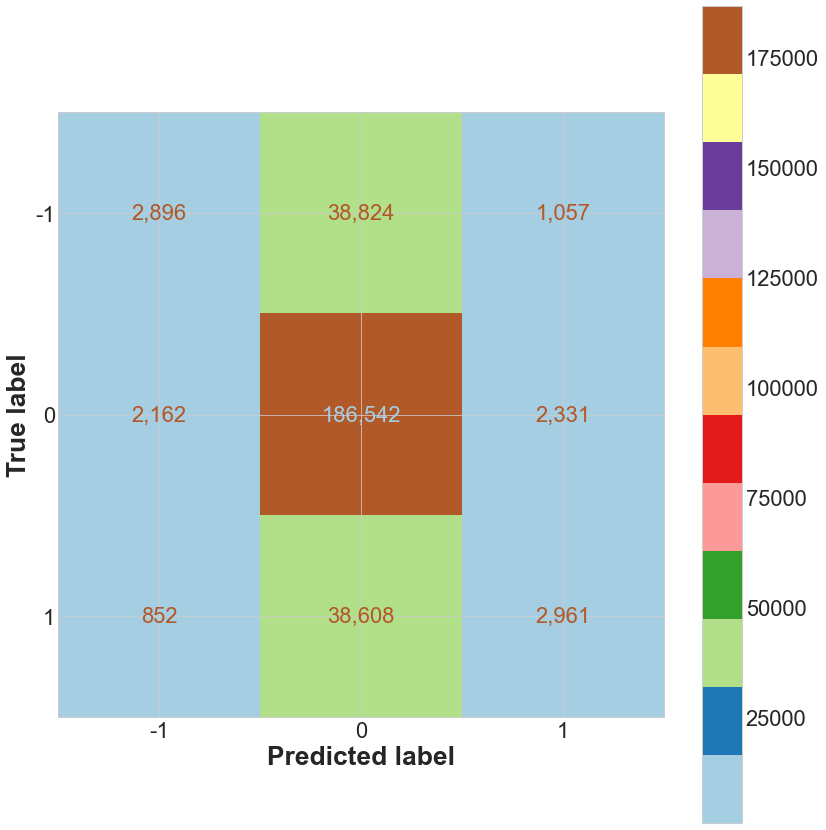

<Figure size 1008x864 with 0 Axes>

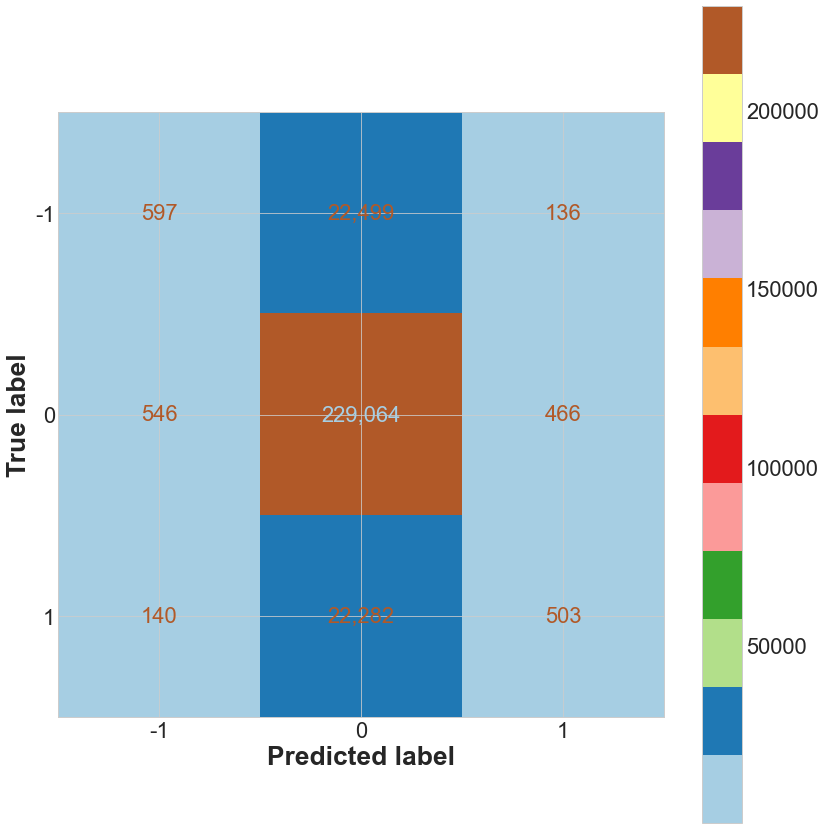

<Figure size 1008x864 with 0 Axes>

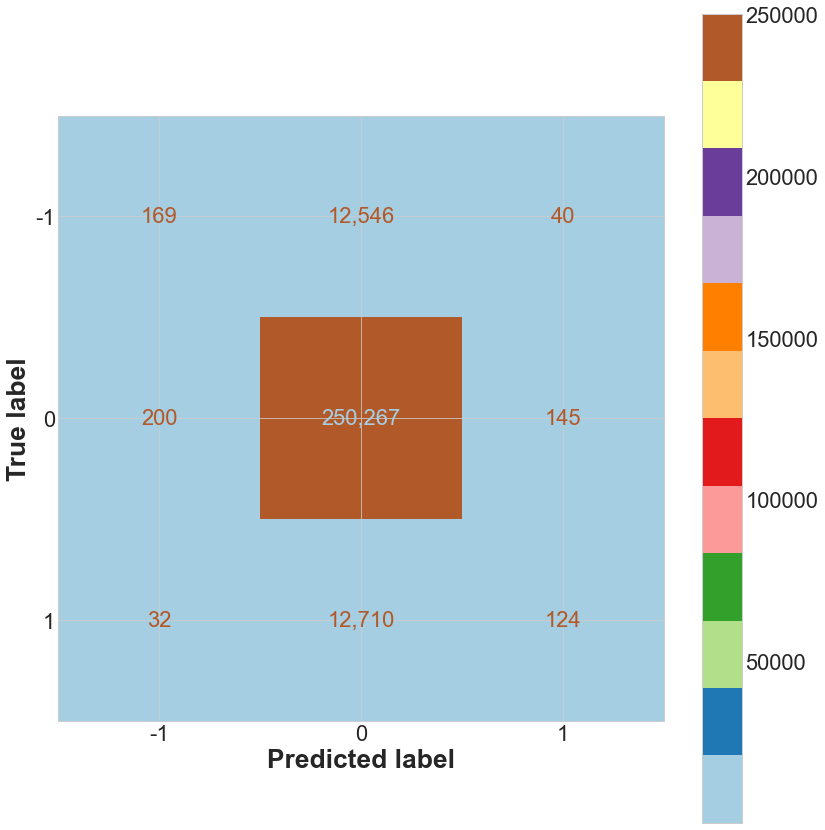

<Figure size 1008x864 with 0 Axes>

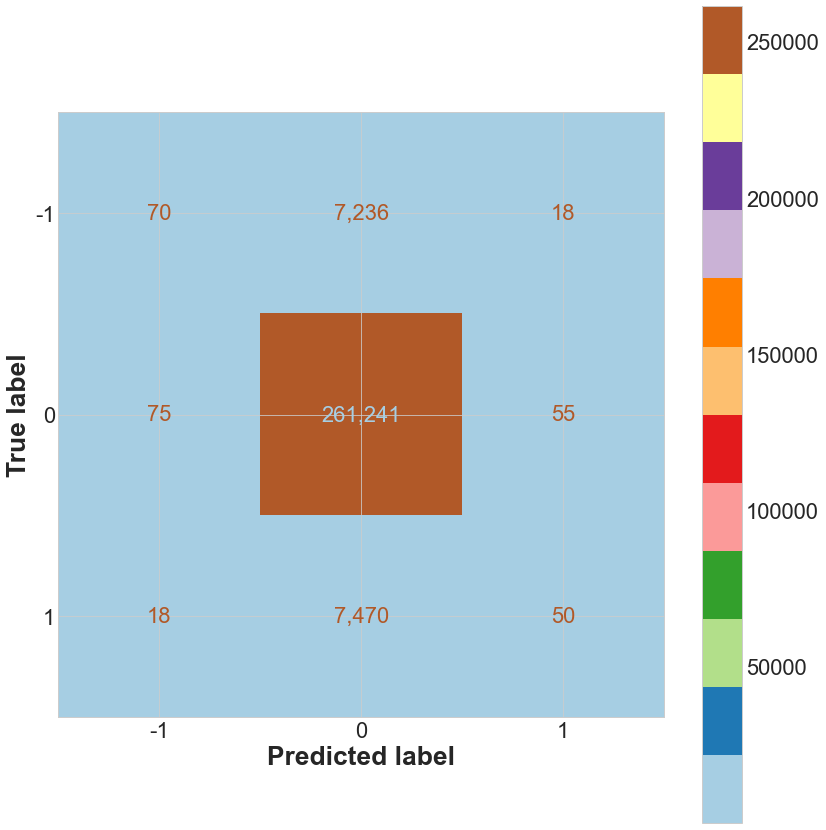

[[  2896  38824   1057]
 [  2162 186542   2331]
 [   852  38608   2961]]
[[   597  22499    136]
 [   546 229064    466]
 [   140  22282    503]]
[[   169  12546     40]
 [   200 250267    145]
 [    32  12710    124]]
[[    70   7236     18]
 [    75 261241     55]
 [    18   7470     50]]


In [159]:
cm_f10 = confusion_matrix(y_test['f5s_10c_arrow'], y_f10_pred, labels=[-1,0,1])
cm_f15 = confusion_matrix(y_test['f5s_15c_arrow'], y_f15_pred, labels=[-1,0,1])
cm_f20 = confusion_matrix(y_test['f5s_20c_arrow'], y_f20_pred, labels=[-1,0,1])
cm_f25 = confusion_matrix(y_test['f5s_25c_arrow'], y_f25_pred, labels=[-1,0,1])
# norm_cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
plot_confusion_matrix2(cm_f10, 'f10_confusion_matrix.png')
plot_confusion_matrix2(cm_f15, 'f15_confusion_matrix.png')
plot_confusion_matrix2(cm_f20, 'f20_confusion_matrix.png')
plot_confusion_matrix2(cm_f25, 'f25_confusion_matrix.png')

print(cm_f10)
print(cm_f15)
print(cm_f20)
print(cm_f25)


In [160]:
print(cm_f10)
print(cm_f15)
print(cm_f20)
print(cm_f25)

[[  2896  38824   1057]
 [  2162 186542   2331]
 [   852  38608   2961]]
[[   597  22499    136]
 [   546 229064    466]
 [   140  22282    503]]
[[   169  12546     40]
 [   200 250267    145]
 [    32  12710    124]]
[[    70   7236     18]
 [    75 261241     55]
 [    18   7470     50]]


In [161]:
cm_f10_json = {}
cm_f10_json.update({"f10_Confusion_Matrix": cm_f10})
mlflow.log_param("f10_confusion_matrix.json", cm_f10_json)
print(cm_f10_json)

cm_f15_json = {}
cm_f15_json.update({"f15_Confusion_Matrix": cm_f15})
mlflow.log_param("f15_confusion_matrix.json", cm_f15_json)
print(cm_f15_json)

cm_f20_json = {}
cm_f20_json.update({"f20_Confusion_Matrix": cm_f20})
mlflow.log_param("f20_confusion_matrix.json", cm_f20_json)
print(cm_f20_json)

cm_f25_json = {}
cm_f25_json.update({"f25_Confusion_Matrix": cm_f25})
mlflow.log_param("f25_confusion_matrix.json", cm_f25_json)
print(cm_f25_json)

{'f10_Confusion_Matrix': array([[  2896,  38824,   1057],
       [  2162, 186542,   2331],
       [   852,  38608,   2961]])}
{'f15_Confusion_Matrix': array([[   597,  22499,    136],
       [   546, 229064,    466],
       [   140,  22282,    503]])}
{'f20_Confusion_Matrix': array([[   169,  12546,     40],
       [   200, 250267,    145],
       [    32,  12710,    124]])}
{'f25_Confusion_Matrix': array([[    70,   7236,     18],
       [    75, 261241,     55],
       [    18,   7470,     50]])}


In [162]:
# from mlflow.models.signature import infer_signature
# signature = infer_signature(x_train, xgb.predict(xgb.DMatrix(data=x_train, label=y_train)))
# mlflow.xgboost.log_model(xgb, "model") #, signature=signature)""
#fig, ax = plt.subplots()
#sns.set(rc = {'figure.figsize':(12,9)})
#ns.heatmap(cm, annot=True, cmap="YlGnBu",fmt='d')
#fig.savefig("ConfusionMatrix.png")
#mlflow.log_figure(fig, "ConfusionMatrix.png")
#plt.show()

#sns.heatmap(cm_pct, annot=True, cmap="YlGnBu", fmt=".3f")
#fig.savefig("ConfusionMatrixPct.png")
#mlflow.log_figure(fig, "ConfusionMatrixPct.png")
#plt.show()


# feature_importances = pd.DataFrame(xgb.feature_importances_,index=x_train.columns.tolist(),columns=['importance'])
# feature_importances.sort_values('importance', ascending=False)


In [163]:
def print_fi(xgb, name):
    feature_importance = pd.DataFrame(xgb.feature_importances_,index=X_train.columns.tolist(),columns=['importance'])
    vals = feature_importance.sort_values('importance', ascending=False)
    mlflow.log_param(name, vals.to_string)
    print (name)
    print(vals)


    #_x = pd.Series(xgb.feature_importances_, index=X_train.columns).nlargest(12).plot(kind='barh')
    _x = pyplot.barh(range(len(xgb.feature_importances_)), xgb.feature_importances_, )
    plt.show()
    #mlflow.log_image(image, name)
    return

f10_feature_importance
             importance
ask_avg        0.175935
ask_max        0.172853
bid_avg        0.121376
h1s_ask_max    0.055889
vix            0.053084
h4s_bid_min    0.050894
h4s_ask_max    0.038679
bid_min        0.037876
h1s_bid_min    0.034698
h1s_bid_avg    0.029923
h2s_ask_max    0.029898
h2s_bid_min    0.029492
h3s_ask_max    0.028559
h3s_bid_min    0.025943
h1s_ask_avg    0.017965
h4s_bid_avg    0.017038
h2s_bid_avg    0.016350
h3s_ask_avg    0.016266
h2s_ask_avg    0.015988
h4s_ask_avg    0.015732
h3s_bid_avg    0.015562


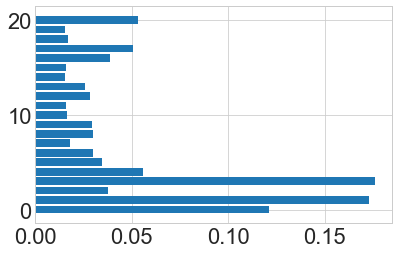

f15_feature_importance
             importance
ask_max        0.165385
ask_avg        0.158928
bid_avg        0.111356
h1s_ask_max    0.073436
h4s_bid_min    0.052319
vix            0.050999
h1s_bid_min    0.046121
h4s_ask_max    0.040052
bid_min        0.031481
h3s_bid_min    0.031242
h3s_ask_max    0.030809
h2s_ask_max    0.028767
h2s_bid_min    0.027900
h1s_bid_avg    0.024054
h1s_ask_avg    0.021496
h3s_bid_avg    0.018022
h4s_bid_avg    0.017986
h3s_ask_avg    0.017893
h2s_ask_avg    0.017550
h4s_ask_avg    0.017361
h2s_bid_avg    0.016843


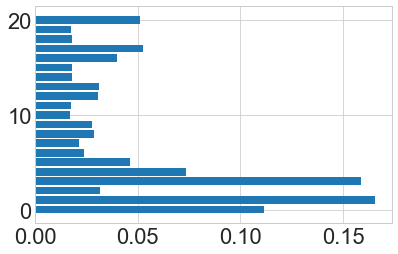

f20_feature_importance
             importance
ask_max        0.167801
ask_avg        0.146278
bid_avg        0.088142
h1s_ask_max    0.083056
h4s_bid_min    0.049218
h1s_bid_min    0.047866
vix            0.044007
h4s_ask_max    0.040961
h2s_bid_min    0.038310
h3s_bid_min    0.036713
h3s_ask_max    0.034312
bid_min        0.031568
h2s_ask_max    0.026389
h1s_bid_avg    0.024495
h1s_ask_avg    0.023893
h4s_bid_avg    0.020418
h4s_ask_avg    0.019938
h3s_ask_avg    0.019546
h3s_bid_avg    0.019544
h2s_ask_avg    0.018942
h2s_bid_avg    0.018604


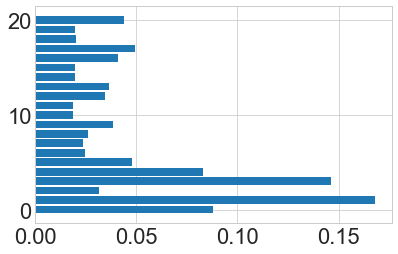

f25_feature_importance
             importance
ask_max        0.161259
ask_avg        0.128196
h1s_ask_max    0.084892
bid_avg        0.075046
h4s_bid_min    0.053866
vix            0.047793
h1s_bid_min    0.042282
h4s_ask_max    0.041783
h2s_bid_min    0.040689
h3s_bid_min    0.036668
h3s_ask_max    0.035762
bid_min        0.033256
h2s_ask_max    0.030433
h1s_ask_avg    0.027350
h1s_bid_avg    0.025332
h3s_ask_avg    0.023712
h4s_bid_avg    0.023140
h3s_bid_avg    0.022756
h4s_ask_avg    0.022705
h2s_ask_avg    0.021904
h2s_bid_avg    0.021178


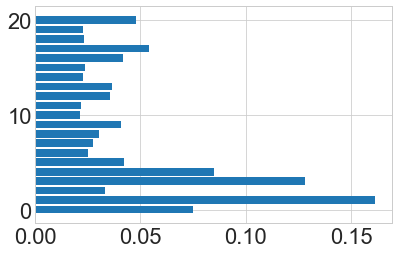

In [164]:
print_fi( xgb_f10, 'f10_feature_importance')
print_fi( xgb_f15, 'f15_feature_importance')
print_fi( xgb_f20, 'f20_feature_importance')
print_fi( xgb_f25, 'f25_feature_importance')

In [165]:
mlflow.end_run()

# ToDo

* add history: h1, h2, h3, h4, h5.  There seems to be no value for >5
* filter time to 9:45 - 15:45
* remove non-full days
* add vix index
* move data to MySQL

DONE:

* Create multiple arrow buckets ('f5s_10c_arrow', 'f5s_20c_arrow') += 'f5s_15c_arrow', 'f5s_25c_arrow', 'f5s_30c_arrow'

In [166]:
data.head(100)

,date,open,high,low,close,volume,average,barCount,date2_str_x,h1s_high,...,h2s_ask_avg,h3s_ask_max,h3s_bid_min,h3s_bid_avg,h3s_ask_avg,h4s_ask_max,h4s_bid_min,h4s_bid_avg,h4s_ask_avg,vix
0,2022-06-24 12:29:54,0.0,0.0000,243.5433,0.0,0.00,-0.0003,0.0,2022-06-24,NaN,...,0.0434,0.0567,-0.0433,-0.0430,0.0500,0.0534,-0.0500,-0.0303,0.0534,27.40
1,2022-06-24 12:29:55,0.0,0.0000,243.5833,0.0,3.27,-0.0003,1.0,2022-06-24,-0.0400,...,0.0034,0.0100,-0.0833,-0.0833,0.0034,0.0167,-0.0833,-0.0830,0.0100,27.40
2,2022-06-24 12:29:56,0.0,0.0000,243.5433,0.0,15.00,-0.0003,1.0,2022-06-24,0.0400,...,0.0400,0.0434,-0.0433,-0.0433,0.0434,0.0500,-0.0433,-0.0433,0.0434,27.40
3,2022-06-24 12:29:57,0.0,0.0000,243.5433,0.0,3.00,-0.0003,1.0,2022-06-24,0.0000,...,0.0400,0.0434,-0.0433,-0.0433,0.0400,0.0434,-0.0433,-0.0433,0.0434,27.40
4,2022-06-24 12:29:58,0.0,0.0000,243.5500,0.0,6.00,0.0000,1.0,2022-06-24,-0.0067,...,0.0367,0.0333,-0.0500,-0.0467,0.0333,0.0367,-0.0500,-0.0500,0.0333,27.40
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,2022-06-24 12:31:29,0.0,0.0033,243.4600,0.0,3.00,0.0010,1.0,2022-06-24,-0.0400,...,-0.0400,-0.0400,-0.1533,-0.1167,-0.0400,-0.0400,-0.1533,-0.1530,-0.0800,27.39
96,2022-06-24 12:31:30,0.0,0.0033,243.4600,0.0,0.00,0.0000,0.0,2022-06-24,0.0033,...,0.0160,-0.0400,-0.1533,-0.1533,-0.0400,-0.0400,-0.1533,-0.1167,-0.0400,27.39
97,2022-06-24 12:31:31,0.0,0.0033,243.4200,0.0,10.50,0.0000,1.0,2022-06-24,0.0433,...,0.0567,0.0833,-0.1133,-0.0343,0.0560,0.0000,-0.1133,-0.1133,0.0000,27.36
98,2022-06-24 12:31:32,0.0,0.0033,243.4200,0.0,0.00,0.0000,0.0,2022-06-24,0.0033,...,0.0037,0.0633,-0.0333,-0.0333,0.0567,0.0833,-0.1133,-0.0343,0.0560,27.36


In [167]:
output = X_test.copy()

In [168]:
cm_f10 = confusion_matrix(y_test['f5s_10c_arrow'], y_f10_pred, labels=[-1,0,1])
cm_f15 = confusion_matrix(y_test['f5s_15c_arrow'], y_f15_pred, labels=[-1,0,1])
cm_f20 = confusion_matrix(y_test['f5s_20c_arrow'], y_f20_pred, labels=[-1,0,1])
cm_f25 = confusion_matrix(y_test['f5s_25c_arrow'], y_f25_pred, labels=[-1,0,1])

In [169]:
print (y_test)
y_test['p_f5s_10c_arrow'] = y_f10_pred
y_test['p_f5s_15c_arrow'] = y_f15_pred
y_test['p_f5s_20c_arrow'] = y_f20_pred
y_test['p_f5s_25c_arrow'] = y_f25_pred
print (y_test)

        f5s_10c_arrow  f5s_15c_arrow  f5s_20c_arrow  f5s_25c_arrow  \
271689           -1.0            0.0            0.0            0.0   
165965            0.0            0.0            0.0            0.0   
63561             0.0            0.0            0.0            0.0   
76915             0.0            0.0            0.0            0.0   
79349             1.0            0.0            0.0            0.0   
...               ...            ...            ...            ...   
807643            0.0            0.0            0.0            0.0   
295688            0.0            0.0            0.0            0.0   
84015             0.0            0.0            0.0            0.0   
816570            0.0            0.0            0.0            0.0   
456337           -1.0           -1.0            0.0            0.0   

        p_f5s_10c_arrow  p_f5s_15c_arrow  p_f5s_20c_arrow  p_f5s_25c_arrow  
271689              0.0              0.0              0.0              0.0  
16596

In [170]:
print(X_test.shape)
print(y_test.shape)

to_save = X_test.join(y_test)
to_save.head(100)

#to_save = X_test.copy()
#to_save[ y_test.columns ] = y_test [ y_test.columns ]
print(to_save.shape)

(276233, 21)
(276233, 8)
(276233, 29)


In [171]:
print (y_test.shape)
print (X_test.shape)
print (to_save.shape)

(276233, 8)
(276233, 21)
(276233, 29)


In [172]:
to_save.head()

,bid_avg,ask_max,bid_min,ask_avg,h1s_ask_max,h1s_bid_min,h1s_bid_avg,h1s_ask_avg,h2s_ask_max,h2s_bid_min,...,h4s_ask_avg,vix,f5s_10c_arrow,f5s_15c_arrow,f5s_20c_arrow,f5s_25c_arrow,p_f5s_10c_arrow,p_f5s_15c_arrow,p_f5s_20c_arrow,p_f5s_25c_arrow
0,-0.529037,-0.064984,-0.690856,0.126272,-0.010018,-0.083789,0.005765,0.037483,-0.148695,-0.060028,...,-0.159259,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0.875121,-0.238770,0.175834,0.083925,-0.038305,0.135118,0.085087,-0.008585,-0.027466,0.096998,...,0.006051,-1.917627,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,-0.359050,-0.195972,0.059697,-0.119972,-0.024161,0.007970,-0.042509,0.019650,-0.002128,0.005792,...,-0.073423,-0.138404,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,-0.640590,-0.367163,-0.344180,-0.066645,0.074422,-0.104980,0.066798,-0.009859,-0.062818,-0.237272,...,-0.131222,-0.778412,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1.702033,0.928446,0.985322,1.468851,-0.094457,0.113927,0.071051,-0.043826,-0.067825,0.036194,...,-0.026299,-0.788013,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [173]:
to_save.to_csv("test_pred.csv")

In [174]:
y_test.head()

,f5s_10c_arrow,f5s_15c_arrow,f5s_20c_arrow,f5s_25c_arrow,p_f5s_10c_arrow,p_f5s_15c_arrow,p_f5s_20c_arrow,p_f5s_25c_arrow
271689,-1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
165965,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
63561,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
76915,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
79349,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [175]:
X_test.head()

,bid_avg,ask_max,bid_min,ask_avg,h1s_ask_max,h1s_bid_min,h1s_bid_avg,h1s_ask_avg,h2s_ask_max,h2s_bid_min,...,h2s_ask_avg,h3s_ask_max,h3s_bid_min,h3s_bid_avg,h3s_ask_avg,h4s_ask_max,h4s_bid_min,h4s_bid_avg,h4s_ask_avg,vix
0,-0.529037,-0.064984,-0.690856,0.126272,-0.010018,-0.083789,0.005765,0.037483,-0.148695,-0.060028,...,-0.112477,-0.122141,-0.286040,-0.083121,-0.092793,-0.184966,-0.394989,-0.275796,-0.159259,NaN
1,0.875121,-0.238770,0.175834,0.083925,-0.038305,0.135118,0.085087,-0.008585,-0.027466,0.096998,...,0.009109,-0.022734,0.100166,0.070695,0.007314,-0.019905,0.086359,0.060828,0.006051,-1.917627
2,-0.359050,-0.195972,0.059697,-0.119972,-0.024161,0.007970,-0.042509,0.019650,-0.002128,0.005792,...,0.014131,-0.010293,-0.074250,-0.020871,0.006940,-0.098828,-0.129202,-0.090977,-0.073423,-0.138404
3,-0.640590,-0.367163,-0.344180,-0.066645,0.074422,-0.104980,0.066798,-0.009859,-0.062818,-0.237272,...,-0.066825,-0.188579,-0.194596,-0.186288,-0.182927,-0.030564,-0.114760,-0.090869,-0.131222,-0.778412
4,1.702033,0.928446,0.985322,1.468851,-0.094457,0.113927,0.071051,-0.043826,-0.067825,0.036194,...,-0.031369,-0.060059,0.029528,-0.000038,-0.030086,-0.052206,0.025247,-0.000347,-0.026299,-0.788013


In [180]:
!say "I'm done!"